# Weather History — Sanity Check (v2)

Fixes datetime detection to work with Arrow-backed dtypes like `string[pyarrow]`.
Edit `PARQUET_PATH` below to your dataset path (file or partitioned directory).

In [1]:
# ==== Parameters (edit here) ====
PARQUET_PATH = "../../datamart/bronze/weather_history"  # change if needed
ROW_LIMIT = None
FORCE_DATETIME_COL = None  # e.g., "valid_date"


In [2]:
import os, pandas as pd, numpy as np
import pyarrow.dataset as ds
import matplotlib.pyplot as plt
from pandas.api.types import is_datetime64_any_dtype

print("pandas:", pd.__version__)
print("numpy:", np.__version__)


pandas: 2.0.3
numpy: 1.24.4


In [3]:
# ---- Load Parquet (file or directory) ----
assert os.path.exists(PARQUET_PATH), f"Path not found: {PARQUET_PATH}"
dataset = ds.dataset(PARQUET_PATH, format="parquet")
table = ds.Scanner.from_dataset(dataset).to_table()
if ROW_LIMIT is not None and table.num_rows > ROW_LIMIT:
    table = table.slice(0, ROW_LIMIT)
df = table.to_pandas(types_mapper=pd.ArrowDtype)  # arrow-backed dtypes
print("Loaded rows:", len(df))
print("Columns:", list(df.columns))
df.head(3)

Loaded rows: 78763
Columns: ['STATION', 'DATE', 'SOURCE', 'LATITUDE', 'LONGITUDE', 'ELEVATION', 'NAME', 'REPORT_TYPE', 'CALL_SIGN', 'QUALITY_CONTROL', 'WND', 'CIG', 'VIS', 'TMP', 'DEW', 'SLP', 'AA1', 'AA2', 'AA3', 'AB1', 'AD1', 'AE1', 'AH1', 'AH2', 'AH3', 'AH4', 'AH5', 'AH6', 'AI1', 'AI2', 'AI3', 'AI4', 'AI5', 'AI6', 'AJ1', 'AK1', 'AL1', 'AM1', 'AN1', 'AT1', 'AT2', 'AT3', 'AT4', 'AT5', 'AU1', 'AU2', 'AU3', 'AW1', 'AW2', 'AW3', 'AW4', 'AX1', 'AX2', 'AX3', 'ED1', 'GA1', 'GA2', 'GA3', 'GA4', 'GD1', 'GD2', 'GD3', 'GD4', 'GE1', 'GF1', 'KA1', 'KA2', 'KB1', 'KB2', 'KB3', 'KC1', 'KC2', 'KD1', 'KD2', 'KE1', 'KG1', 'KG2', 'MA1', 'MD1', 'MF1', 'MG1', 'MH1', 'MK1', 'MV1', 'MW1', 'MW2', 'MW3', 'OC1', 'OD1', 'OE1', 'OE2', 'OE3', 'RH1', 'RH2', 'RH3', 'REM', 'EQD', 'obs_ts', 'snapshot_date', 'station_id']


,STATION,DATE,SOURCE,LATITUDE,LONGITUDE,ELEVATION,NAME,REPORT_TYPE,CALL_SIGN,QUALITY_CONTROL,...,OE2,OE3,RH1,RH2,RH3,REM,EQD,obs_ts,snapshot_date,station_id
0,72502014734,2023-01-01T00:51:00,7,40.68275,-74.16927,1.9,"NEWARK LIBERTY INTERNATIONAL AIRPORT, NJ US",FM-15,KEWR,V030,...,<NA>,<NA>,<NA>,<NA>,<NA>,MET15012/31/22 19:51:03 METAR KEWR 010051Z 220...,<NA>,2023-01-01 00:51:00,2023-01-01,72502014734
1,72502014734,2023-01-01T01:51:00,7,40.68275,-74.16927,1.9,"NEWARK LIBERTY INTERNATIONAL AIRPORT, NJ US",FM-15,KEWR,V030,...,<NA>,<NA>,<NA>,<NA>,<NA>,MET14012/31/22 20:51:03 METAR KEWR 010151Z 180...,<NA>,2023-01-01 01:51:00,2023-01-01,72502014734
2,72502014734,2023-01-01T02:49:00,6,40.68275,-74.16927,1.9,"NEWARK LIBERTY INTERNATIONAL AIRPORT, NJ US",FM-16,KEWR,V030,...,<NA>,<NA>,<NA>,<NA>,<NA>,MET13512/31/22 21:49:03 SPECI KEWR 010249Z 230...,<NA>,2023-01-01 02:49:00,2023-01-01,72502014734


In [4]:
# ---- Robust datetime detection ----
from typing import Optional

def try_find_datetime_col(df: pd.DataFrame) -> Optional[str]:
    if FORCE_DATETIME_COL and FORCE_DATETIME_COL in df.columns:
        return FORCE_DATETIME_COL
    
    # 1) Prefer columns already recognized as datetime64 (any tz)
    for c in df.columns:
        try:
            if is_datetime64_any_dtype(df[c].dtype):
                return c
        except Exception:
            pass
    
    # 2) Heuristic name match, then attempt to parse a sample
    candidates = [c for c in df.columns if any(k in c.lower() for k in ["date","time","stamp","valid"])]
    for c in candidates:
        try:
            pd.to_datetime(df[c].head(500), errors="raise")
            return c
        except Exception:
            continue
    return None

dt_col = try_find_datetime_col(df)
print("Detected datetime column:", dt_col)

if dt_col is not None:
    # Coerce to UTC-aware datetimes safely (works for strings and naive datetimes)
    df[dt_col] = pd.to_datetime(df[dt_col], errors="coerce", utc=True)
    print("Date range:", df[dt_col].min(), "->", df[dt_col].max())
else:
    print("No datetime column detected. Set FORCE_DATETIME_COL to override.")


Detected datetime column: obs_ts
Date range: 2023-01-01 00:00:00+00:00 -> 2024-12-31 23:51:00+00:00


In [5]:
# ---- Basic nulls and dtypes ----
summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "null_count": df.isna().sum(),
    "non_null": df.notna().sum()
}).sort_values("null_count", ascending=False)
summary.head(20)

,dtype,null_count,non_null
AH3,string[pyarrow],78708,55
AH1,string[pyarrow],78708,55
AH2,string[pyarrow],78708,55
AH6,string[pyarrow],78708,55
AH5,string[pyarrow],78708,55
AH4,string[pyarrow],78708,55
AI6,string[pyarrow],78707,56
AI5,string[pyarrow],78707,56
AI4,string[pyarrow],78707,56
AI3,string[pyarrow],78707,56


In [6]:
# ---- Numeric stats (quick) ----
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[num_cols].describe().T if num_cols else pd.DataFrame()
desc.head(20)

""


In [7]:
# ---- Station/airport popularity (best-guess columns) ----
station_like = None
for k in ["station","icao","wban","usaf","sid","station_id","airport"]:
    cands = [c for c in df.columns if k in c.lower()]
    if cands:
        station_like = cands[0]
        break

if station_like:
    top_stations = df[station_like].value_counts().head(20)
    print("Station-like column:", station_like)
    display(top_stations)
else:
    print("No obvious station/airport column found.")

Station-like column: STATION


STATION
72503014732    27061
74486094789    26471
72502014734    25231
Name: count, dtype: int64[pyarrow]

,_day,size
0,2023-01-01,114
1,2023-01-02,95
2,2023-01-03,130
3,2023-01-04,117
4,2023-01-05,154


,_month,size
0,2023-01-01,3401
1,2023-02-01,2945
2,2023-03-01,3349
3,2023-04-01,3287
4,2023-05-01,3085


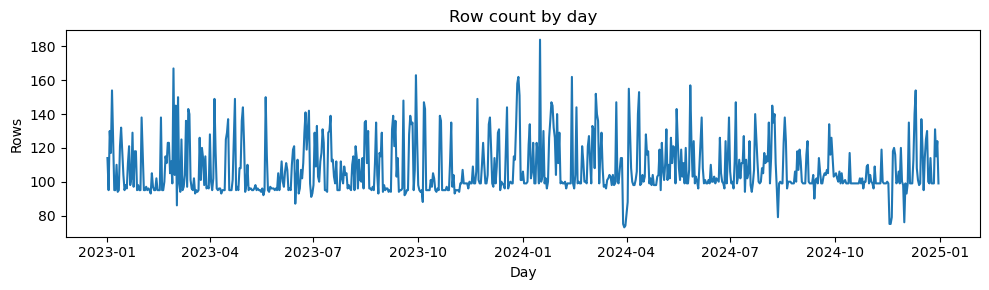

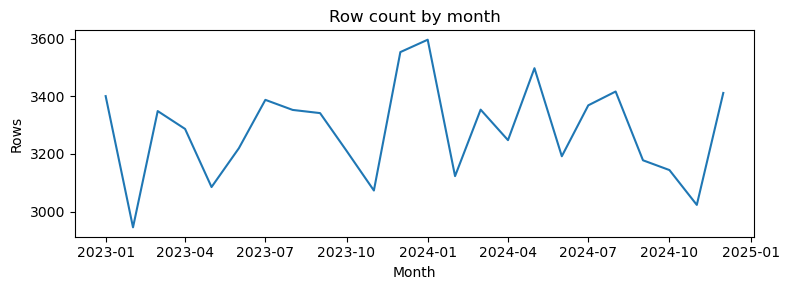

In [8]:
# ---- Aggregations by day/month with plots ----
if dt_col is not None:
    # If tz-aware, drop tz for plotting
    if getattr(df[dt_col].dt, "tz", None) is not None:
        date_series = df[dt_col].dt.tz_convert(None)
    else:
        date_series = df[dt_col]
    df["_day"] = date_series.dt.date
    df["_month"] = date_series.dt.to_period("M").dt.to_timestamp()

    by_day = df.groupby("_day", as_index=False).size()
    by_month = df.groupby("_month", as_index=False).size()

    display(by_day.head()); display(by_month.head())

    plt.figure(figsize=(10,3)); plt.plot(by_day["_day"], by_day["size"])
    plt.title("Row count by day"); plt.xlabel("Day"); plt.ylabel("Rows"); plt.tight_layout(); plt.show()

    plt.figure(figsize=(8,3)); plt.plot(by_month["_month"], by_month["size"])
    plt.title("Row count by month"); plt.xlabel("Month"); plt.ylabel("Rows"); plt.tight_layout(); plt.show()
else:
    print("Skipping day/month plots: no datetime column detected.")

In [9]:
# ---- Per-station per-day pivot (top N stations) ----
if dt_col is not None and station_like:
    topN = df[station_like].value_counts().head(10).index
    small = df[df[station_like].isin(topN)].copy()
    # reuse tz-dropped version
    if getattr(df[dt_col].dt, "tz", None) is not None:
        small["_date"] = small[dt_col].dt.tz_convert(None)
    else:
        small["_date"] = small[dt_col]
    small["_day"] = small["_date"].dt.date
    piv = small.pivot_table(index="_day", columns=station_like, values=dt_col, aggfunc="count").fillna(0).astype(int)
    piv.head()
else:
    print("Skipping station/day pivot: need both datetime and station columns.")